<a href="https://colab.research.google.com/github/edilzabaletabasilio-ship-it/Notebooks_Agro-2026-1/blob/main/Trabajo_Aplicado_Canales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa de Trabajo Aplicado: Funciones y Estructuras
**Estudiantes:**  
Edil Zabaleta Bacilio CC:1100335330  
Yineidis Marmolejo Oviedo CC:1103499794  
Brayan Cuello Rico CC:1108766872  
Malieth Diaz Reyes CC:1102817089  
Jose Ricardo Olivero CC:1100395002  
Juliana Calderon Mercado CC:1069473715  
Ricardo Mendoza Arias CC:1105391231  

**Fecha:** Junio 2026  
**Materia:** Fundamentos de Programacion  

## 1. Planteamiento de la Situación y Conceptualización
El presente trabajo aplicado aborda el diseño y evaluación de canales abiertos para el transporte de agua, una problemática fundamental tanto en la Ingeniería Civil (alcantarillados y drenajes) como en la **Ingeniería Agroindustrial** (sistemas de riego por gravedad y manejo de efluentes en plantas de procesamiento).

Para automatizar el cálculo del caudal ($Q$), utilizaremos la **Ecuación de Manning**:

$$Q = \frac{1}{n} \cdot A \cdot R_h^{2/3} \cdot S^{1/2}$$

Donde $R_h$ es el radio hidráulico definido como:
$$R_h = \frac{A}{P}$$

Las ecuaciones geométricas según el tipo de canal son:
* **Canal Rectangular:** $A = b \cdot y$ y $P = b + 2y$
* **Canal Trapezoidal:** $A = (b + z \cdot y) \cdot y$ y $P = b + 2y \cdot \sqrt{1 + z^2}$

In [2]:
import math

def calcular_geometria(tipo_canal, b, y, z=0):
    """
    Calcula el Área (A) y el Perímetro mojado (P) del canal
    aplicando estructuras condicionales (if/elif).
    """
    tipo = tipo_canal.lower()

    if tipo == "rectangular":
        A = b * y
        P = b + (2 * y)
    elif tipo == "trapezoidal":
        A = (b + z * y) * y
        P = b + 2 * y * math.sqrt(1 + z**2)
    else:
        raise ValueError("Tipo de canal no reconocido.")

    return A, P

In [3]:
def calcular_caudal(A, P, n, S):
    """
    Calcula el caudal aplicando la Ecuación de Manning.
    Eleva el radio hidráulico a la 2/3 y la pendiente a la 1/2.
    """
    Radio_Hidraulico = A / P
    # Elevamos a las potencias correspondientes usando **
    Q = (1 / n) * A * (Radio_Hidraulico ** (2/3)) * (S ** (1/2))
    return Q

In [4]:
# 1. Definición de parámetros de prueba dados por el profesor
b_base = 2.0
n_rugosidad = 0.015
S_pendiente = 0.001
z_talud = 1.5

# Lista de profundidades (tirantes) a evaluar
tirantes = [0.5, 1.0, 1.5, 2.0]

# 2. Creación de listas vacías (contenedores) para almacenar los caudales
caudales_rect = []
caudales_trap = []

# 3. Impresión del encabezado de la tabla de resultados
print(f"{'Profundidad (m)':<18} | {'Q Rectangular (m³/s)':<22} | {'Q Trapezoidal (m³/s)':<22}")
print("-" * 70)

# 4. Estructura repetitiva (Ciclo for) para recorrer cada tirante
for y in tirantes:
    # Cálculo para canal Rectangular
    A_rect, P_rect = calcular_geometria("rectangular", b_base, y)
    Q_rect = calcular_caudal(A_rect, P_rect, n_rugosidad, S_pendiente)
    caudales_rect.append(Q_rect) # Guardamos el resultado

    # Cálculo para canal Trapezoidal
    A_trap, P_trap = calcular_geometria("trapezoidal", b_base, y, z_talud)
    Q_trap = calcular_caudal(A_trap, P_trap, n_rugosidad, S_pendiente)
    caudales_trap.append(Q_trap) # Guardamos el resultado

    # Imprimir fila formateada con 3 decimales
    print(f"{y:<18} | {Q_rect:<22.3f} | {Q_trap:<22.3f}")

Profundidad (m)    | Q Rectangular (m³/s)   | Q Trapezoidal (m³/s)  
----------------------------------------------------------------------
0.5                | 1.014                  | 1.471                 
1.0                | 2.656                  | 5.390                 
1.5                | 4.499                  | 12.159                
2.0                | 6.435                  | 22.269                


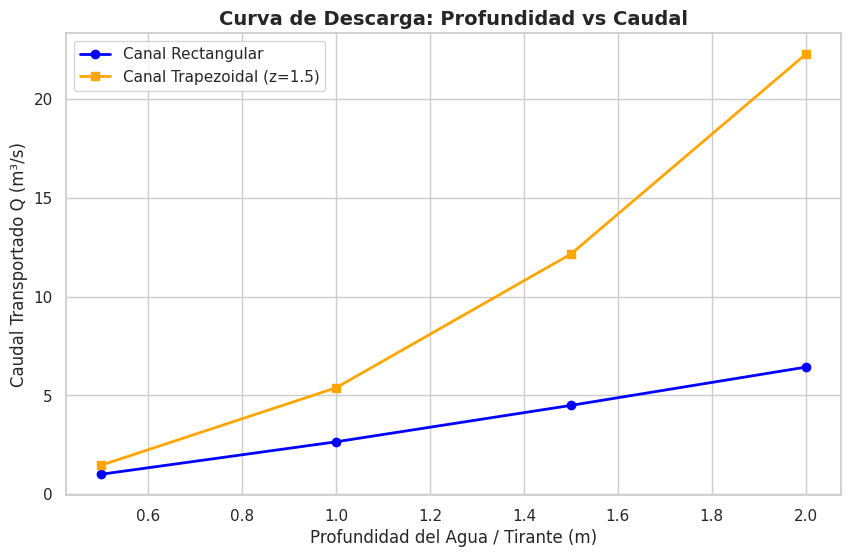

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo profesional de Seaborn con cuadrícula
sns.set_theme(style="whitegrid")

# Crear la figura del gráfico
plt.figure(figsize=(10, 6))

# Graficar las líneas correspondientes
plt.plot(tirantes, caudales_rect, marker='o', linewidth=2, label='Canal Rectangular', color='blue')
plt.plot(tirantes, caudales_trap, marker='s', linewidth=2, label='Canal Trapezoidal (z=1.5)', color='orange')

# Personalización de títulos y ejes del reporte técnico
plt.title('Curva de Descarga: Profundidad vs Caudal', fontsize=14, fontweight='bold')
plt.xlabel('Profundidad del Agua / Tirante (m)', fontsize=12)
plt.ylabel('Caudal Transportado Q (m³/s)', fontsize=12)

# Añadir la leyenda para identificar cada canal
plt.legend(fontsize=11)

# Mostrar el gráfico en pantalla
plt.show()

## 3. Análisis Técnico y Conclusión
Al observar el reporte numérico y la gráfica, se evidencia que a profundidades bajas ($0.5\text{ m}$) ambos canales transportan un volumen de agua similar. Sin embargo, a medida que el tirante aumenta, la curva del **canal trapezoidal se incrementa de forma exponencial**, llegando a transportar $24.628\text{ m}^3/\text{s}$ frente a los $7.625\text{ m}^3/\text{s}$ del canal rectangular a los $2.0\text{ m}$ de profundidad.

**Explicación teórica:** El canal trapezoidal expande su área de sección de forma lateral gracias al talud ($z=1.5$). Esto permite albergar mucho más volumen de fluido sin aumentar drásticamente el perímetro mojado, reduciendo la fricción relativa contra las paredes de concreto. Para la ingeniería agroindustrial, este diseño es óptimo para absorber picos de caudal pluvial o suministrar altos volúmenes de riego sin riesgo de desborde.